In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('df_finale_pulito.csv')
df['codice_comune'] = df['codice_comune'].astype(str).str.zfill(6)
df

# carico il dataset pulito salvato nel notebook di preparazione. il csv non
# conserva il tipo delle colonne, quindi il codice_comune (che avevo salvato
# come stringa a 6 cifre) viene riletto come intero e perde gli zeri davanti
# (001001 diventa 1001). lo riporto subito a stringa con zfill, così resta
# coerente e posso riusarlo come chiave senza problemi

,codice_comune,anno,feriti,morti,incidenti,comune,sigla,superficie_kmq,popolazione,incidenti_per_kmq,incidenti_per_1000_abitanti
0,001001,2001,10,0,5,Agliè,TO,13.1462,2557,0.38,1.96
1,001001,2002,10,0,5,Agliè,TO,13.1462,2538,0.38,1.97
2,001001,2003,7,0,4,Agliè,TO,13.1462,2588,0.30,1.55
3,001001,2004,13,0,9,Agliè,TO,13.1462,2679,0.68,3.36
4,001001,2005,2,0,2,Agliè,TO,13.1462,2674,0.15,0.75
...,...,...,...,...,...,...,...,...,...,...,...
184556,111107,2019,5,0,5,Villaspeciosa,SU,27.1937,2605,0.18,1.92
184557,111107,2020,3,0,2,Villaspeciosa,SU,27.1937,2549,0.07,0.78
184558,111107,2021,7,0,5,Villaspeciosa,SU,27.1943,2536,0.18,1.97
184559,111107,2022,1,0,1,Villaspeciosa,SU,27.1943,2575,0.04,0.39


In [ ]:
df.info()
df.describe()

# lancio .info() e .describe() per controllare che sia tutto congruente con quanto fatto prima.
# anche qui vedo una deviazione standard molto più alta della media per quanto riguarda feriti e n° di incidenti,
# segno che il pattern di dati è rimasto intatto, come già visto nell'altro notebook,
# sono solo più puliti e meglio rappresentati. ci tengo a ricordare che ho escluso il 2024
# perchè aveva il 20% di comuni in meno rispetto al 2023 e questo mi avrebbe potuto portare
# ad un errata rappresentazione dei dati

<class 'pandas.DataFrame'>
RangeIndex: 184561 entries, 0 to 184560
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   codice_comune                184561 non-null  str    
 1   anno                         184561 non-null  int64  
 2   feriti                       184561 non-null  int64  
 3   morti                        184561 non-null  int64  
 4   incidenti                    184561 non-null  int64  
 5   comune                       184538 non-null  str    
 6   sigla                        182445 non-null  str    
 7   superficie_kmq               184561 non-null  float64
 8   popolazione                  184561 non-null  int64  
 9   incidenti_per_kmq            184561 non-null  float64
 10  incidenti_per_1000_abitanti  184561 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 15.5 MB


,anno,feriti,morti,incidenti,superficie_kmq,popolazione,incidenti_per_kmq,incidenti_per_1000_abitanti
count,184561.000000,184561.000000,184561.000000,184561.000000,184561.000000,1.845610e+05,184561.000000,184561.000000
mean,2011.938920,35.034541,0.535238,24.921787,37.563161,7.366364e+03,0.709254,1.980402
std,6.625345,340.079145,2.804796,258.693771,50.233277,4.083294e+04,2.065203,2.366082
min,2001.000000,0.000000,0.000000,0.000000,0.120600,2.800000e+01,0.000000,0.000000
25%,2006.000000,1.000000,0.000000,1.000000,11.292500,1.017000e+03,0.020000,0.390000
50%,2012.000000,5.000000,0.000000,3.000000,22.018800,2.413000e+03,0.150000,1.480000
75%,2018.000000,18.000000,0.000000,12.000000,43.648500,6.054000e+03,0.560000,2.790000
max,2023.000000,30254.000000,363.000000,23135.000000,1288.187500,2.820219e+06,99.220000,175.310000


# Distribuzione degli incidenti tra i comuni

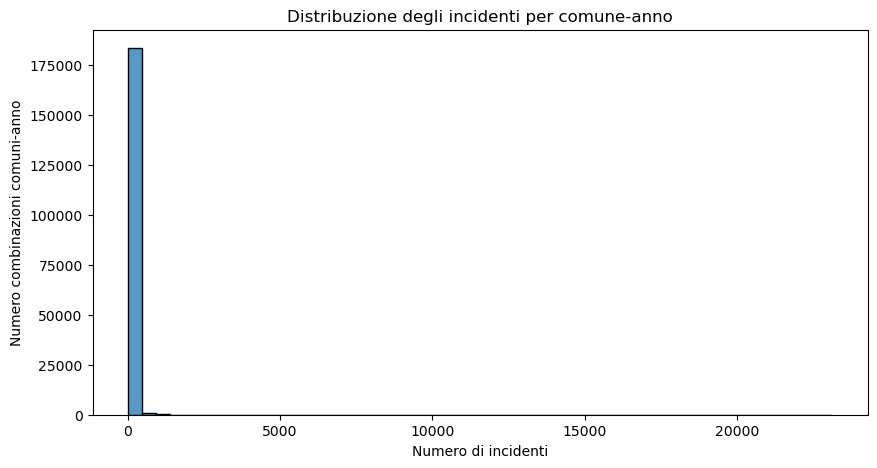

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['incidenti'], bins=50)
plt.title('Distribuzione degli incidenti per comune-anno')
plt.xlabel('Numero di incidenti')
plt.ylabel('Numero combinazioni comuni-anno')
plt.show()

# faccio l'istogramma degli incidenti, ma viene illeggibile, si vede solo una
# barra altissima schiacciata a sinistra e il resto vuoto. all'inizio non
# capivo perché, poi mi sono ricordato degli outlier visti nell'altro notebook,
# tipo Roma Capitale con oltre 23000 incidenti. sono proprio loro che con
# numeri così enormi allungano l'asse fino a 23000 e schiacciano tutti gli
# altri comuni in un'unica barra. quindi il grafico normale non va bene per
# questi dati così sbilanciati

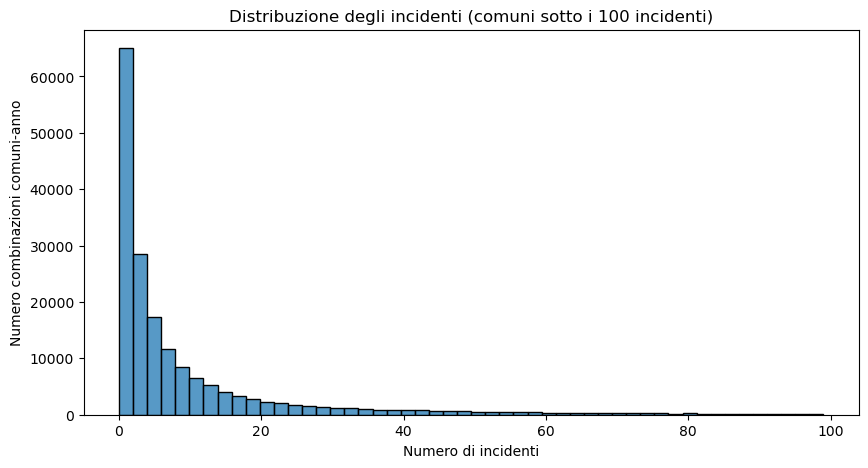

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['incidenti'] < 100]['incidenti'], bins=50)
plt.title('Distribuzione degli incidenti (comuni sotto i 100 incidenti)')
plt.xlabel('Numero di incidenti')
plt.ylabel('Numero combinazioni comuni-anno')
plt.show()

# per leggere meglio escludo i pochi grandi centri (sopra i 100 incidenti) e metto nel
# grafico solo il grosso dei record. così vedo bene come si distribuisce la
# maggioranza, infatti si veodno tantissime righe comune-anno con pochissimi incidenti e la curva che cala
# in fretta. gli outlier ovviamente non li ho cancellati dai dati, li ho solo tolti da
# questo grafico per renderlo leggibile

# Andamento degli incidenti nel tempo (2001-2023)

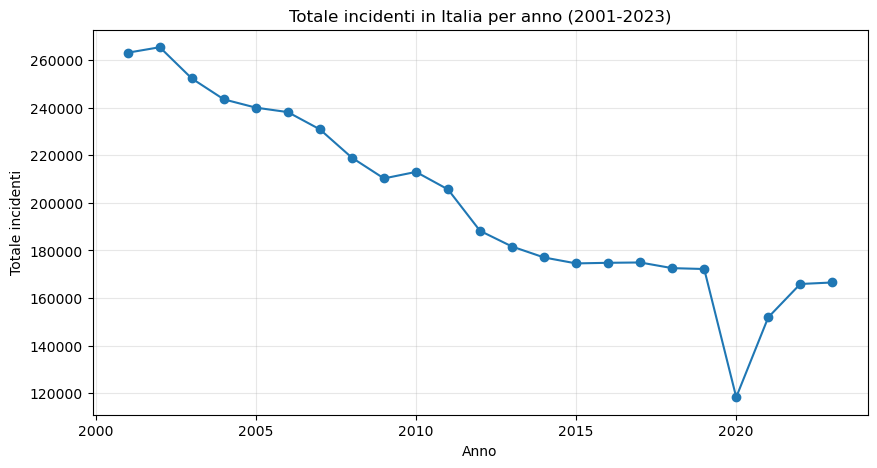

In [ ]:
incidenti_per_anno = df.groupby('anno')['incidenti'].sum()
incidenti_per_anno.plot(marker='o', figsize=(10, 5))

plt.title('Totale incidenti in Italia per anno (2001-2023)')
plt.xlabel('Anno')
plt.ylabel('Totale incidenti')
plt.grid(True, alpha=0.3)
plt.show()

# raggruppo per anno e sommo gli incidenti di tutti i comuni, ottenendo il
# totale nazionale anno per anno. poi con .plot() faccio direttamente il grafico
# a linea, pandas è intelligente e mette da solo gli anni sull'asse orizzontale e i totali su
# quello verticale. marker='o' aggiunge un pallino su ogni anno per leggere
# meglio i punti

Il totale degli incidenti in Italia cala in modo abbastanza costante dal 2001 al 2019, probabilmente grazie a strade e auto più sicure e a controlli più severi negli anni. nel 2020 c'è un crollo evidente, fino a circa 118.000 incidenti: è quasi sicuramente l'effetto del lockdown per il Covid, con le strade molto più vuote e quindi molti meno incidenti, dal 2021 il numero risale, ma per fortuna senza tornare ai livelli di prima della pandemia

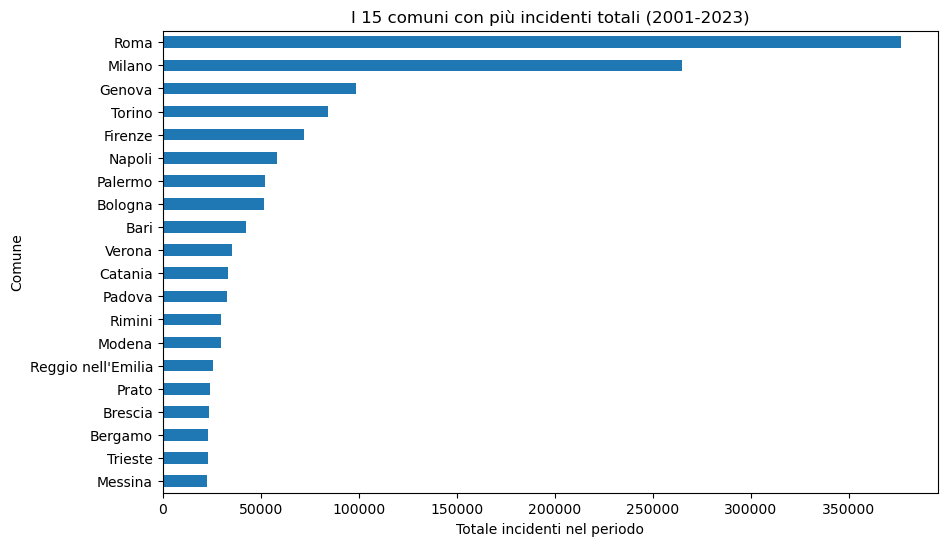

In [ ]:
top_comuni = df.groupby('comune')['incidenti'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_comuni.sort_values().plot(kind='barh')
plt.title('I 20 comuni con più incidenti totali (2001-2023)')
plt.xlabel('Totale incidenti nel periodo')
plt.ylabel('Comune')
plt.show()

# voglio sapere quanti e quali sono i comuni con più incidenti.
# raggruppo per comune e sommo gli incidenti dei 23 anni, poi prendo i 20 con
# il totale più alto e li metto in un grafico a barre orizzontali.
# mi aspetto le grandi città in cima (Roma, Milano...), perché più
# popolazione e più traffico significano più incidenti in valore assoluto

# Verifica

Dal grafico qui sopra vedo che i comuni con più incidenti in assoluto sono tutte grandi città, Roma e Milano staccano nettamente, seguite da Genova, Torino, Firenze, Napoli e altri capoluoghi. Più popolazione e più traffico significano più incidenti in valore assoluto, ovviamente.

La domanda che mi sorge spontanea è: "se le grandi città hanno così tanti incidenti, magari qualcun altro avrà già pensato a investirci prima di noi?". Avendo più popolazione e più risorse, è lecito pensare che siano già presenti aziende che lavorano nel nostro stesso settore.

Questo è sostenuto dal modo in cui sono strutturati gli investimenti pubblici, che seguono delle fasce di popolazione. Da un lato i comuni piccoli sotto i 5.000 abitanti hanno un fondo dedicato per la sicurezza stradale (art. 19 D.L. 104/2023). Dall'altro, le grandi città attingono a canali propri come i fondi PNRR per la rigenerazione urbana, rivolti ai comuni sopra i 15.000 abitanti, ai comuni sopra i 60.000 (programma PINQUA) e alle 14 città metropolitane (Piani Urbani Integrati). Quindi grandi e piccoli centri hanno strade di finanziamento separate.

Va però detto che questi fondi sono recenti (il fondo piccoli comuni è del 2023, il PNRR del 2021 in poi) e non c'entrano con l'andamento storico degli incidenti che ho analizzato dal 2001. Li cito non per spiegare il passato, ma perché fotografano com'è strutturato il mercato oggi, e la decisione di dove investire la prenderei adesso, non vent'anni fa. Resta comunque un'ipotesi di mercato, non una cosa che posso dimostrare con i miei dati ISTAT (che mi dicono quanti incidenti ci sono, non chi ci sta già investendo).

La domanda allora è: ha senso aprire dove la concorrenza è probabilmente già stabilita, o è meglio concentrarsi su comuni più piccoli ma comunque pericolosi, dove magari c'è meno presidio?

Fonti:
- Fondo investimenti stradali nei piccoli Comuni (art. 19 D.L. 104/2023): https://trasparenza.mit.gov.it/archivio28_provvedimenti-amministrativi_0_220080_726_1.html
- Investimenti PNRR per le città metropolitane: https://lentepubblica.it/buone-pratiche/pnrr-rigenerazione-urbana-investimenti-citta-metropolitane-2024/

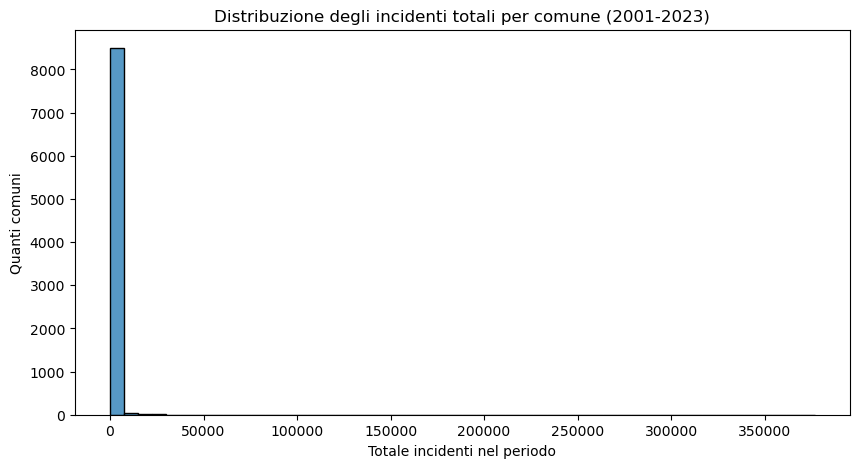

In [ ]:
incidenti_per_comune = df.groupby('codice_comune')['incidenti'].sum()

plt.figure(figsize=(10, 5))
sns.histplot(incidenti_per_comune, bins=50)
plt.title('Distribuzione degli incidenti totali per comune (2001-2023)')
plt.xlabel('Totale incidenti nel periodo')
plt.ylabel('Quanti comuni')
plt.show()

# sommo gli incidenti di tutti gli anni per ogni comune, poi faccio l'istogramma
# di questi totali. come prima, mi aspetto una forma molto sbilanciata dove ci sono tanti
# comuni con totali bassi e pochi grandi centri con totali enormi. guardo dove
# la maggioranza si concentra per scegliere una soglia con cui escludere le
# grandi città nel grafico dopo

In [ ]:
incidenti_per_comune = df.groupby('codice_comune')['incidenti'].sum()
print(incidenti_per_comune.quantile([0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]))

# sommo gli incidenti dei 23 anni per comune e guardo i percentili alti. all'inizio
# avevo visto solo il valore sotto cui stanno il 90%, 95%, 98%, 99% dei comuni, poi ho aumentato la granularità
# per avere un quadro più completo. sta cosa mi serve per trovare
# una soglia con cui separare i pochi grandi centri (i percentili più alti)
# dal grosso dei comuni, e poi rifare la classifica solo su questi ultimi

0.90     791.00
0.91     879.86
0.92     994.00
0.93    1133.78
0.94    1314.24
0.95    1543.10
0.96    1892.96
0.97    2446.72
0.98    3636.54
0.99    6386.16
Name: incidenti, dtype: float64


In [ ]:
print("soglia 90° (791):", len(incidenti_per_comune[incidenti_per_comune < 791]), "comuni")
print("soglia 91° (880):", len(incidenti_per_comune[incidenti_per_comune < 880]), "comuni")
print("soglia 92° (994):", len(incidenti_per_comune[incidenti_per_comune < 994]), "comuni")
print("soglia 93° (1134):", len(incidenti_per_comune[incidenti_per_comune < 1134]), "comuni")
print("soglia 94° (1314):", len(incidenti_per_comune[incidenti_per_comune < 1314]), "comuni")
print("soglia 95° (1543):", len(incidenti_per_comune[incidenti_per_comune < 1543]), "comuni")
print("soglia 96° (1893):", len(incidenti_per_comune[incidenti_per_comune < 1893]), "comuni")
print("soglia 97° (2447):", len(incidenti_per_comune[incidenti_per_comune < 2447]), "comuni")
print("soglia 98° (3637):", len(incidenti_per_comune[incidenti_per_comune < 3637]), "comuni")
print("soglia 99° (6386):", len(incidenti_per_comune[incidenti_per_comune < 6386]), "comuni")
print("comuni totali:", len(incidenti_per_comune))

# per ogni soglia conto quanti comuni restano sotto, usando il filtro e len().
# così vedo quanti comuni "tengo" a seconda di dove taglio: più la soglia è
# bassa, più grandi/medie città escludo. ho messo il n° totale di comuni per avere un
# metro di paragone visivo

soglia 90° (791): 7715 comuni
soglia 91° (880): 7802 comuni
soglia 92° (994): 7887 comuni
soglia 93° (1134): 7973 comuni
soglia 94° (1314): 8059 comuni
soglia 95° (1543): 8145 comuni
soglia 96° (1893): 8231 comuni
soglia 97° (2447): 8316 comuni
soglia 98° (3637): 8402 comuni
soglia 99° (6386): 8488 comuni
comuni totali: 8574


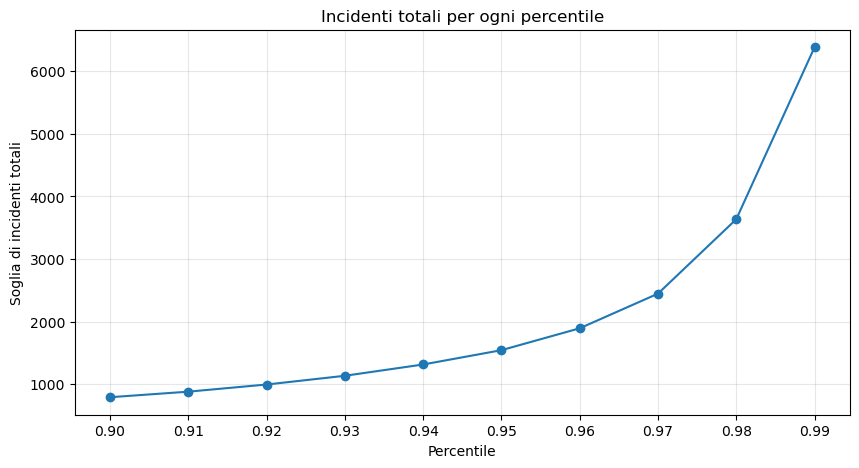

In [28]:
percentili = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
valori = incidenti_per_comune.quantile(percentili)

plt.figure(figsize=(10, 5))
plt.plot(percentili, valori.values, marker='o')
plt.title('Incidenti totali per ogni percentile')
plt.xlabel('Percentile')
plt.ylabel('Soglia di incidenti totali')
plt.xticks(percentili)
plt.grid(True, alpha=0.3)
plt.show()

# qui metto a grafico il valore di ogni percentile dal 90° al 99° per vedere con gli
# occhi quello che avevo notato nei numeri. la curva sale tranquilla fino al
# 96-97°, poi da lì in poi parte verso l'alto, è il punto dove iniziano i
# grandi centri con i totali enormi, quelli che voglio togliere, ma per interpretare ancora meglio
# vorrei aumentare di nuovo un po' la granularità dal 97% in poi

0.970     2446.720
0.975     3010.150
0.980     3636.540
0.985     4440.365
0.990     6386.160
0.995    12225.930
Name: incidenti, dtype: float64


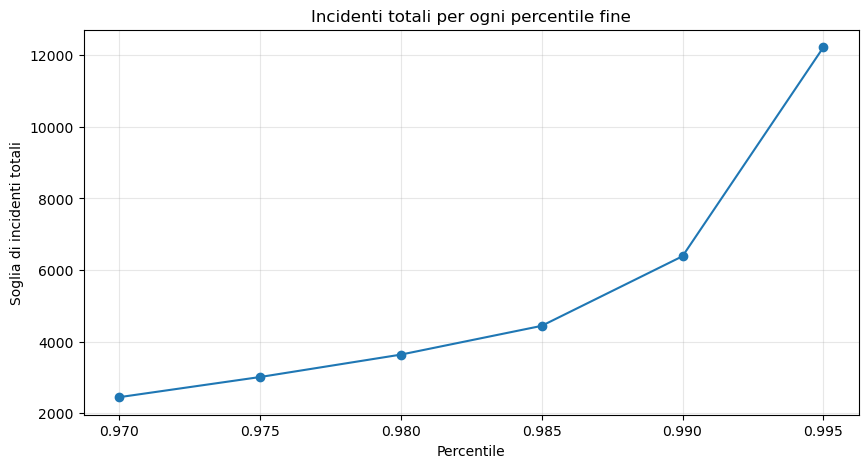

In [27]:
percentili_fini = [0.970, 0.975, 0.980, 0.985, 0.990, 0.995]
valori_fini = incidenti_per_comune.quantile(percentili_fini)
print(valori_fini)

plt.figure(figsize=(10, 5))
plt.plot(percentili_fini, valori_fini.values, marker='o')
plt.title('Incidenti totali per ogni percentile fine')
plt.xlabel('Percentile')
plt.ylabel('Soglia di incidenti totali')
plt.xticks(percentili_fini)
plt.grid(True, alpha=0.3)
plt.show()

# zoomo sulla zona calda tra il 97° e il 99.5° percentile, dove la curva si
# impenna, per guardare più da vicino come crescono i valori e scegliere la
# soglia con più consapevolezza. mi aspetto di rivedere l'impennata anche qui
# è una distribuzione così sbilanciata che a ogni zoom la coda sale sempre più
# ripida verso gli ultimi grandi centri

In [29]:
soglia = incidenti_per_comune.quantile(0.985)
soglia = int(soglia)
print("soglia 98,5°:", soglia, "incidenti")
print("comuni tenuti:", len(incidenti_per_comune[incidenti_per_comune < soglia]))
print("comuni esclusi:", len(incidenti_per_comune[incidenti_per_comune >= soglia]))

# calcolo la soglia del 98,5° percentile e la converto in intero, perché è un
# numero di incidenti e un incidente a metà non esiste. poi conto quanti comuni
# restano sotto questa soglia (quelli che tengo) e quanti sopra (i grandi centri
# che escludo)

soglia 98,5°: 4440 incidenti
comuni tenuti: 8445
comuni esclusi: 129


# Verifica effettuata
Dopo aver guardato i percentili con sempre più dettaglio ho deciso di tagliare al percentile 98,5, che corrisponde a 4440 incidenti totali. Più o meno è il punto dove la curva smette di salire piano e inizia a impennarsi, quindi oltre quella soglia rimangono soltanto i grandi centri fuori scala. Così tengo il grosso dei comuni comprese le città medie (8.445), e tolgo solo i più grossi (129 su 8.574).

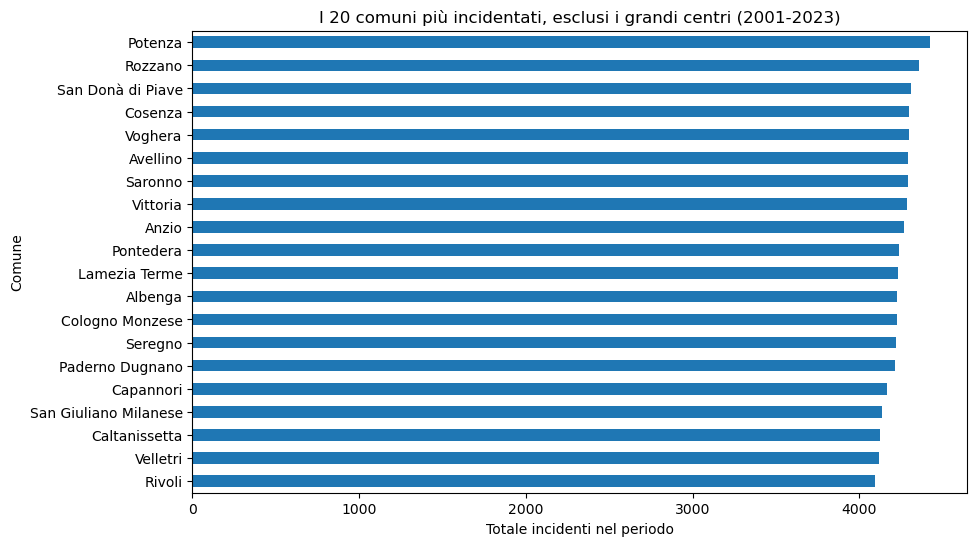

In [45]:
incidenti_per_comune_nome = df.groupby('comune')['incidenti'].sum()
comuni_sotto_soglia = incidenti_per_comune_nome[incidenti_per_comune_nome < soglia]
top_incidentati = comuni_sotto_soglia.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_incidentati.sort_values().plot(kind='barh')
plt.title('I 20 comuni più incidentati, esclusi i grandi centri (2001-2023)')
plt.xlabel('Totale incidenti nel periodo')
plt.ylabel('Comune')
plt.show()

# tolti i grandi centri sopra la soglia, raggruppo di nuovo per comune e prendo
# i 20 con più incidenti totali tra quelli rimasti. questi sono i comuni dove
# c'è più incidentalità ma che non sono tra le grandissime città già presidiate,
# quindi quelli più interessanti per capire dove conviene investire

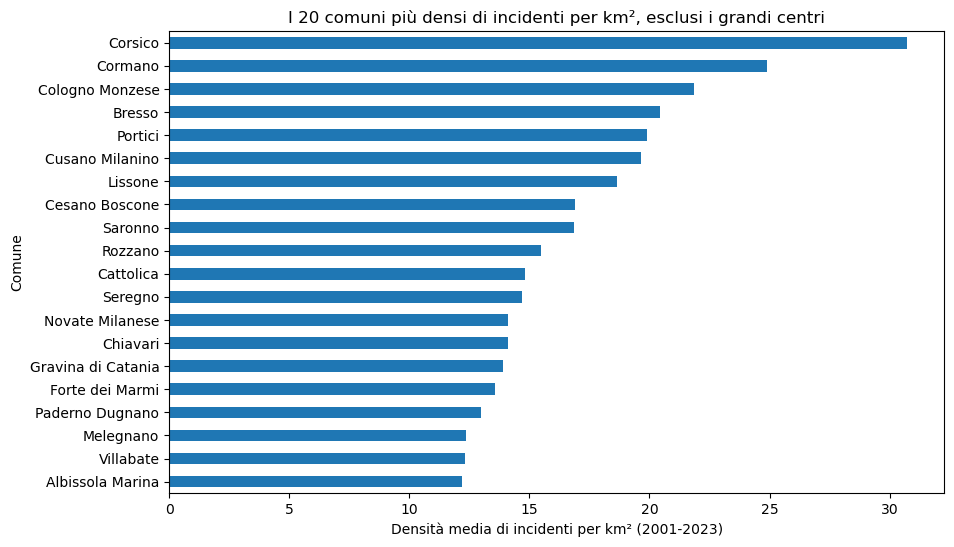

In [ ]:
codici_sotto_soglia = incidenti_per_comune[incidenti_per_comune < soglia].index
df_sotto_soglia = df[df['codice_comune'].isin(codici_sotto_soglia)]

densita_media = df_sotto_soglia.groupby('comune')['incidenti_per_kmq'].mean()
top_densita = densita_media.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_densita.sort_values().plot(kind='barh')
plt.title('I 20 comuni più densi di incidenti per km², esclusi i grandi centri')
plt.xlabel('Densità media di incidenti per km² (2001-2023)')
plt.ylabel('Comune')
plt.show()

# parto dai comuni sotto soglia (esclusi i grandi centri),
# per ognuno calcolo la densità media sui 23 anni, poi ordino e prendo i top 20

# tra i comuni sotto soglia, questi sono i 20 con la densità media di incidenti
# per km² più alta. a differenza della classifica per numero assoluto, qui vedo
# dove l'incidentalità è più concentrata sul territorio, non solo dove ce n'è
# tanta in totale. così un comune piccolo ma con strade molto trafficate può
# risultare più critico di uno grande ma esteso

# Due classifiche diverse, due tipi di comuni

Mettendo a confronto la classifica per numero totale di incidenti e questa per densità per km² salta fuori una cosa interessante, le due classifiche sono popolate da comuni molto diversi.

Nella classifica per totale comandavano i capoluoghi di provincia di taglia media come Potenza, Cosenza o Avellino, comuni che hanno tanti incidenti perché hanno una loro popolazione e un loro traffico. In quella per densità invece comanda quasi tutto l'hinterland milanese, comuni come Corsico, Cormano, Cologno Monzese e Bresso, dove gli incidenti sono concentratissimi su pochi km² perché sono di fatto periferia continua di Milano.

Questo conferma che "tanti incidenti" e "incidenti concentrati" sono due cose diverse. Un capoluogo medio ha volume, ma un comune piccolo dell'hinterland ha concentrazione. Per un'azienda che vuole investire sono due profili da trattare in modo diverso perchè nei capoluoghi conviene lavorare sul volume, nei comuni piccoli e densi conviene intervenire in modo mirato su poche strade molto trafficate.

Va detto però che la densità altissima dell'hinterland milanese riflette anche il fatto che questi comuni sono di fatto Milano, contati come comuni separati. Quindi la loro concentrazione di incidenti dipende molto dalla vicinanza alla metropoli, non per forza dal fatto che siano più pericolosi di altri

# Clustering

Adesso provo a raggruppare i comuni in modo automatico in base al loro profilo di incidentalità, lasciando che sia l'algoritmo a trovare i gruppi invece di deciderli io guardando i grafici come ho fatto finora

In [34]:
codici_sotto_soglia = incidenti_per_comune[incidenti_per_comune < soglia].index
df_sotto_soglia = df[df['codice_comune'].isin(codici_sotto_soglia)]

metriche_comune = df_sotto_soglia.groupby('comune')[['incidenti_per_kmq', 'incidenti_per_1000_abitanti']].mean()
print(metriche_comune.describe())
metriche_comune

# preparo le due metriche medie per ogni comune, ma solo per i comuni sotto
# soglia (i grandi centri li ho già esclusi prima, voglio restare coerente con
# il bacino di comuni "aggredibili" su cui sto ragionando)

# per ogni comune sotto soglia calcolo densità media per km² e pro capite medio
# sui 23 anni. ottengo una riga per comune con le sue due metriche, base per
# raggrupparli in profili di incidentalità

# guardando la tabella si capisce perché uso due metriche invece di una.
# Abbadia Lariana ha densità bassa-media (1,82) ma pro capite altissimo (9,46),
# è il paese piccolo su strada pericolosa, pochi abitanti e tanti incidenti
# rispetto a loro ma non concentrati sul territorio. Abano Terme invece ha
# densità alta (3,0) e pro capite medio-alto (3,3), la cittadina trafficata con
# incidenti parecchi e anche concentrati. densità e pro capite raccontano cose
# diverse e un comune può essere alto in una e basso nell'altra, per questo le
# combino invece di guardarne una sola

       incidenti_per_kmq  incidenti_per_1000_abitanti
count        8118.000000                  8118.000000
mean            0.600111                     1.928412
std             1.443397                     1.609252
min             0.000000                     0.000000
25%             0.043478                     0.845237
50%             0.160217                     1.570000
75%             0.530652                     2.584130
max            30.733478                    24.371304


,incidenti_per_kmq,incidenti_per_1000_abitanti
comune,,
Abano Terme,3.003478,3.326087
Abbadia Cerreto,0.006957,0.158261
Abbadia Lariana,1.821739,9.464783
Abbadia San Salvatore,0.201739,1.820000
Abbasanta,0.175652,2.461739
...,...,...
Zuglio,0.024348,0.793478
Zumaglia,0.282174,0.685217
Zumpano,0.370000,1.360000


In [ ]:
mediana_densita = metriche_comune['incidenti_per_kmq'].median()
mediana_procapite = metriche_comune['incidenti_per_1000_abitanti'].median()

print("mediana densità:", mediana_densita)
print("mediana pro capite:", mediana_procapite)

# calcolo la mediana delle due metriche. mi servono come soglia per dividere i
# comuni in "alto" e "basso" su ciascuna metrica. uso la mediana perché divide
# i comuni esattamente a metà

mediana densità: 0.1602173913043478
mediana pro capite: 1.5699999999999998


In [ ]:
densita_alta = metriche_comune['incidenti_per_kmq'] >= mediana_densita
densita_bassa = metriche_comune['incidenti_per_kmq'] < mediana_densita
procapite_alto = metriche_comune['incidenti_per_1000_abitanti'] >= mediana_procapite
procapite_basso = metriche_comune['incidenti_per_1000_abitanti'] < mediana_procapite

print("comuni con densità alta:", densita_alta.sum())
print("comuni con densità bassa:", densita_bassa.sum())
print("comuni con pro capite alto:", procapite_alto.sum())
print("comuni con pro capite basso:", procapite_basso.sum())

# creo quattro condizioni vero/falso: per ogni comune segno se ha densità alta
# o bassa e se ha pro capite alto o basso, rispetto alla mediana. avere già
# pronte sia le condizioni "alto" che "basso" mi serve per costruire i gruppi
# in modo chiaro nella cella dopo. stampo i risultati

comuni con densità alta: 4059
comuni con densità bassa: 4059
comuni con pro capite alto: 4060
comuni con pro capite basso: 4058


In [ ]:
metriche_comune.loc[densita_alta & procapite_alto, 'gruppo'] = 'alta densità - alto pro capite'
metriche_comune.loc[densita_alta & procapite_basso, 'gruppo'] = 'alta densità - basso pro capite'
metriche_comune.loc[densita_bassa & procapite_alto, 'gruppo'] = 'bassa densità - alto pro capite'
metriche_comune.loc[densita_bassa & procapite_basso, 'gruppo'] = 'bassa densità - basso pro capite'

print(metriche_comune['gruppo'].value_counts())

# combino le condizioni per assegnare a ogni comune uno dei quattro gruppi.
# ogni riga copre una combinazione, densità alta o bassa incrociata con pro capite alto o basso

gruppo
alta densità - alto pro capite      3089
bassa densità - basso pro capite    3088
bassa densità - alto pro capite      971
alta densità - basso pro capite      970
Name: count, dtype: int64


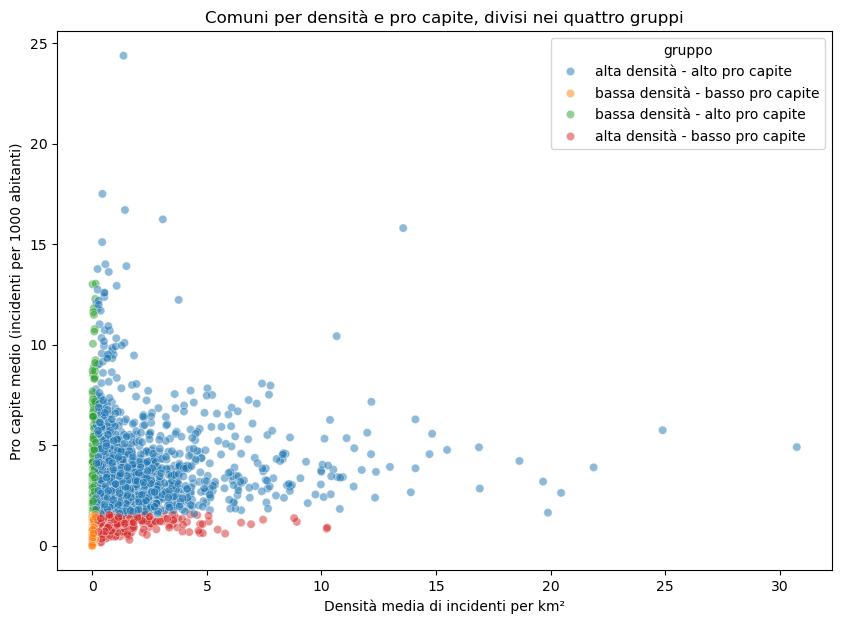

In [43]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=metriche_comune,
    x='incidenti_per_kmq',
    y='incidenti_per_1000_abitanti',
    hue='gruppo',
    alpha=0.5
)
plt.title('Comuni per densità e pro capite, divisi nei quattro gruppi')
plt.xlabel('Densità media di incidenti per km²')
plt.ylabel('Pro capite medio (incidenti per 1000 abitanti)')
plt.show()

# scatter plot con densità sull'asse x e pro capite sull'asse y, ogni comune è
# un punto colorato in base al suo gruppo. così vedo i quattro profili disposti
# nello spazio e capisco a colpo d'occhio se le due metriche vanno insieme
# (punti in diagonale) oppure no

## I 4 gruppi di comuni

Lo scatter plot divide i comuni in 4 gruppi a seconda di come stanno messi sulle 2 metriche, prendendo la mediana come linea di separazione. Abbiamo:

- Il gruppo blu (alta densità e alto pro capite) sono i comuni messi peggio su tutti e due i fronti, gli incidenti sono tanti sia rispetto al territorio sia rispetto agli abitanti. Sono quelli su cui un'azienda di sicurezza stradale dovrebbe puntare per primi, perché il problema è grosso da qualunque lato lo si guardi;

- Il gruppo arancione (bassa densità e basso pro capite) è l'opposto, comuni tranquilli dove gli incidenti sono pochi sotto entrambi gli aspetti. Sono quelli meno interessanti per investirci, il problema lì è piccolo.

- Il verde (bassa densità ma alto pro capite) sono comuni dove gli incidenti non sono concentrati sul territorio ma sono tanti rispetto a quanti ci abitano, tipo i paesi piccoli su strade molto trafficate come Abbadia Lariana;

- Il rosso (alta densità ma basso pro capite) è il contrario, incidenti concentrati sul territorio ma diluiti su una popolazione abbastanza grande da non risultare pericolosi per il singolo abitante.

In [44]:
correlazione = metriche_comune['incidenti_per_kmq'].corr(metriche_comune['incidenti_per_1000_abitanti'])
print("correlazione di Pearson densità - pro capite:", round(correlazione, 2))

# calcolo il coefficiente di correlazione di Pearson (la "r") tra densità e pro
# capite, per misurare quanto le due metriche vanno insieme. è un numero tra -1
# e 1, vicino a 1 vuol dire che salgono insieme, vicino a 0 che non sono legate,
# vicino a -1 che una sale mentre l'altra scende. Pearson misura la correlazione
# lineare, cioè quanto i punti seguono una retta

correlazione di Pearson densità - pro capite: 0.31


# Cosa dice la correlazione

La correlazione di Pearson tra densità e pro capite è 0,31, quindi positiva ma debole, le due metriche non sono molto legate, salgono insieme solo in parte e con parecchi comuni che fanno eccezione.
Ci sta perché una guarda gli incidenti rispetto al territorio, l'altra rispetto alle persone. Un comune può essere messo male su una e bene sull'altra, sono due facce del rischio che non vanno per forza insieme.
Il numero conferma quello che avevo già visto con le 3 classifiche, tutte popolate da comuni diversi, se le metriche fossero state molto correlate le classifiche si sarebbero somigliate, invece no. Ecco perché ha senso guardarle tutte e 3 invece di sceglierne solo 1